In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from ModelGrafo import Disciplina

### Criando Disciplinas

In [2]:
disciplinas = {}


def criar_disciplina(codigo, nome, carga=64):

    d = Disciplina(
        codigo,
        nome,
        carga
    )

    disciplinas[codigo] = d

    return d

# Cadastro das Disciplinas
# ===== 1º SEMESTRE =====

mat00A = criar_disciplina(
    "MAT00A",
    "Cálculo A"
)

xmac01 = criar_disciplina(
    "XMAC01",
    "Matemática Discreta"
)

xdes01 = criar_disciplina(
    "XDES01",
    "Fundamentos de Programação"
)

crsc03 = criar_disciplina(
    "CRSC03",
    "Arquitetura de Computadores I"
)



# ===== 2º SEMESTRE =====

mat002 = criar_disciplina(
    "MAT002",
    "Cálculo B"
)

cmac04 = criar_disciplina(
    "CMAC04",
    "Modelagem Computacional"
)

ctcO01 = criar_disciplina(
    "CTCO01",
    "Algoritmos e Estruturas de Dados I"
)

crsc04 = criar_disciplina(
    "CRSC04",
    "Arquitetura de Computadores II"
)



# ===== 3º SEMESTRE =====

ctc002 = criar_disciplina(
    "CTC002",
    "Algoritmos e Estruturas de Dados II"
)

xdes02 = criar_disciplina(
    "XDES02",
    "Programação Orientada a Objetos"
)

crsc02 = criar_disciplina(
    "CRSC02",
    "Sistemas Operacionais"
)


ctc004 = criar_disciplina(
    "CTC004",
    "Projeto e Análise de Algoritmos"
)

xdes03 = criar_disciplina(
    "XDES03",
    "Programação Web"
)


# ===== 4º SEMESTRE =====

xahc02 = criar_disciplina(
    "XAHC02",
    "Interação Humano-Computador"
)

xcsc01 = criar_disciplina(
    "XCSC01",
    "Redes de Computadores"
)


# ===== 5º SEMESTRE =====

ctc005 = criar_disciplina(
    "CTC005",
    "Teoria da Computação"
)

ctc006 = criar_disciplina(
    "CTC006",
    "Compiladores"
)

xpad01 = criar_disciplina(
    "XPAD01",
    "Banco de Dados I"
)

xmco01 = criar_disciplina(
    "XMCO01",
    "Inteligência Artificial"
)



# ===== 6º/7º =====

xahc03 = criar_disciplina(
    "XAHC03",
    "Metodologia Científica"
)

tcc1 = criar_disciplina(
    "TCC1",
    "Trabalho de Conclusão de Curso 1",
    140
)

tcc2 = criar_disciplina(
    "TCC2",
    "Trabalho de Conclusão de Curso 2",
    210
)

### Adicionando os pré-requisitos

In [3]:
mat002.adicionar_pre_requisito(mat00A)

cmac04.adicionar_pre_requisito(mat00A)


cmac03 = criar_disciplina(
    "CMAC03",
    "Algoritmos em Grafos"
)

cmac03.adicionar_pre_requisito(xmac01)


ctcO01.adicionar_pre_requisito(xdes01)

crsc04.adicionar_pre_requisito(crsc03)



ctc002.adicionar_pre_requisito(ctcO01)

xdes02.adicionar_pre_requisito(ctcO01)

crsc02.adicionar_pre_requisito(crsc04)



ctc004.adicionar_pre_requisito(ctc002)

xdes03.adicionar_pre_requisito(xdes02)


xahc02.adicionar_pre_requisito(xdes03)


xcsc01.adicionar_pre_requisito(crsc02)



ctc005.adicionar_pre_requisito(ctc004)

ctc006.adicionar_pre_requisito(ctc005)



tcc1.adicionar_pre_requisito(ctc006)

xahc03.adicionar_pre_requisito(xahc02)


tcc2.adicionar_pre_requisito(tcc1)

### Criando o Grafo

In [4]:
grafo = nx.DiGraph()


for disciplina in disciplinas.values():

    grafo.add_node(disciplina)



for disciplina in disciplinas.values():

    for requisito in disciplina.pre_requisitos:

        grafo.add_edge(
            requisito,
            disciplina
        )

### Histórico do aluno

In [5]:
df = pd.read_csv("dataset_historico_aluno.csv")
df.head()

,codigo_disciplina,disciplina,carga_horaria,periodo,situacao,nota_final,status
0,MAT00A,Cálculo A,64,2023.1,REP,0.0,Reprovado
1,MAT00A,Cálculo A,64,2023.2,REP,0.1,Reprovado
2,MAT00A,Cálculo A,64,2024.1,REPMF,3.5,Reprovado
3,MAT00A,Cálculo A,64,2025.1,MATR,NaN,Matriculado
4,CAHC04,Projeto Integrado,32,2023.1,APR,7.2,Aprovado


In [6]:
def criar_historico(df):
    historico = {}

    df_ordenado = df.sort_values("periodo")  # garante ordem cronológica

    for linha in df_ordenado.itertuples():
        codigo = linha.codigo_disciplina
        situacao = linha.situacao

        if situacao == "APR":
            historico[codigo] = "CONCLUIDA"
        elif situacao in ["REP", "REPMF"]:
            historico[codigo] = "REPROVADA"

    return historico

In [7]:
# Gera o histórico do aluno
historico_aluno = criar_historico(df)


historico_aluno

{'MAT00A': 'REPROVADA',
 'XMAC01': 'CONCLUIDA',
 'CRSC03': 'REPROVADA',
 'XDES01': 'CONCLUIDA',
 'CAHC04': 'CONCLUIDA',
 'CTCO01': 'REPROVADA',
 'IEPG21': 'CONCLUIDA',
 'CDES05': 'CONCLUIDA',
 'ADM51H': 'CONCLUIDA',
 'XDES04': 'CONCLUIDA',
 'XMCO01': 'CONCLUIDA',
 'XDES11': 'CONCLUIDA',
 'XAHC01': 'CONCLUIDA'}

### Atualizar Grafo

In [8]:
for disciplina in disciplinas.values():
    if disciplina.codigo in historico_aluno:
        disciplina.estado = historico_aluno[disciplina.codigo]

### Encontrar Disciplinas disponíveis

In [9]:
def encontrar_disponiveis():

    disponiveis = []


    for disciplina in disciplinas.values():


        if disciplina.estado != "NAO_CURSADA":

            continue


        liberada = True


        for requisito in disciplina.pre_requisitos:


            if requisito.estado != "CONCLUIDA":

                liberada = False



        if liberada:

            disciplina.estado = "DISPONIVEL"

            disponiveis.append(disciplina)



    return disponiveis

In [10]:
resultado = encontrar_disponiveis()
for d in resultado:
    print(f"{d.codigo} - {d.nome}")

XPAD01 - Banco de Dados I
CMAC03 - Algoritmos em Grafos


### Ordenação Topológica

In [11]:
ordem = nx.topological_sort(grafo)


for disciplina in ordem:

    print(
        f"{disciplina.codigo} - {disciplina.nome}"
    )

MAT00A - Cálculo A
XMAC01 - Matemática Discreta
XDES01 - Fundamentos de Programação
CRSC03 - Arquitetura de Computadores I
XPAD01 - Banco de Dados I
XMCO01 - Inteligência Artificial
MAT002 - Cálculo B
CMAC04 - Modelagem Computacional
CMAC03 - Algoritmos em Grafos
CTCO01 - Algoritmos e Estruturas de Dados I
CRSC04 - Arquitetura de Computadores II
CTC002 - Algoritmos e Estruturas de Dados II
XDES02 - Programação Orientada a Objetos
CRSC02 - Sistemas Operacionais
CTC004 - Projeto e Análise de Algoritmos
XDES03 - Programação Web
XCSC01 - Redes de Computadores
CTC005 - Teoria da Computação
XAHC02 - Interação Humano-Computador
CTC006 - Compiladores
XAHC03 - Metodologia Científica
TCC1 - Trabalho de Conclusão de Curso 1
TCC2 - Trabalho de Conclusão de Curso 2


### Mostrar Grafo

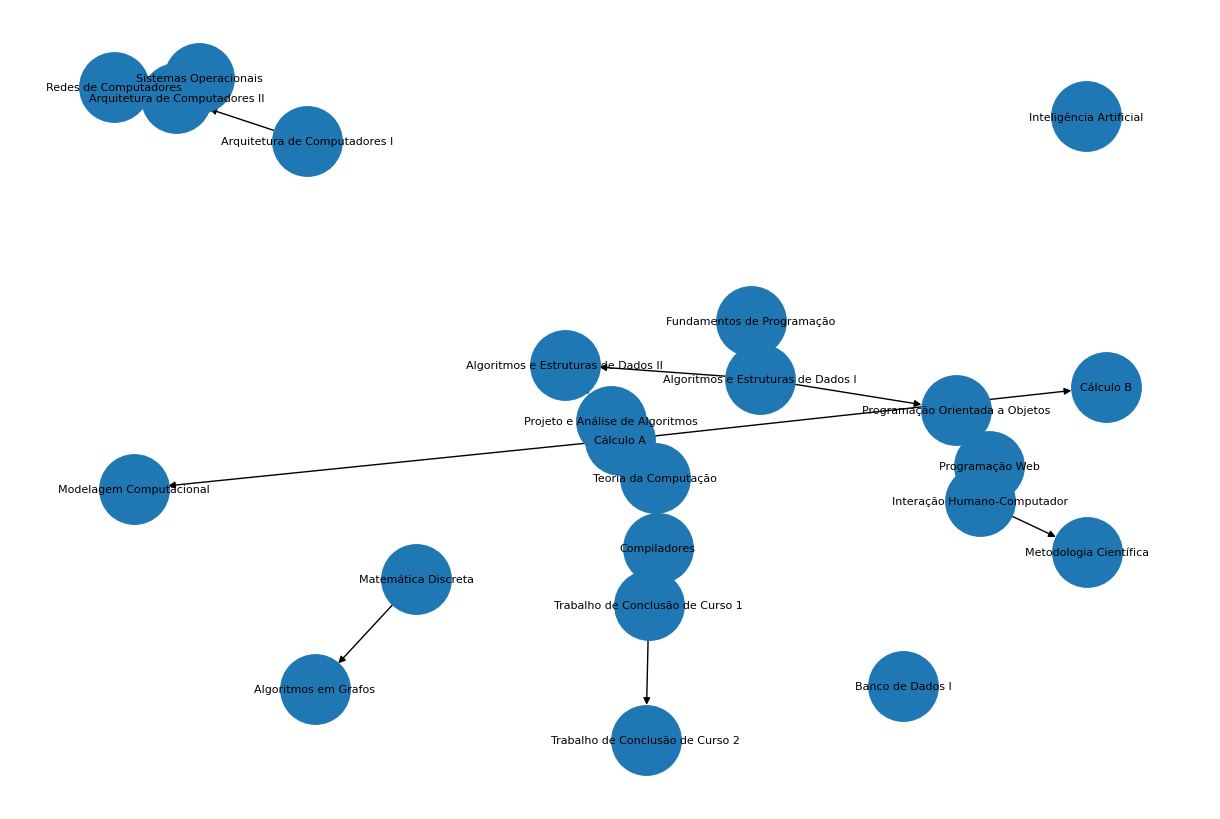

In [12]:
plt.figure(figsize=(12,8))


pos = nx.spring_layout(grafo)


labels = {

    disciplina: disciplina.nome

    for disciplina in grafo.nodes

}


nx.draw(
    grafo,
    pos,
    labels=labels,
    with_labels=True,
    node_size=2500,
    font_size=8
)


plt.show()